===CARGA DE DATOS===

In [1]:
import pandas as pd
import numpy as np

In [2]:
#Leer datos de csv, try-except por si existe un error en la lectura 
# de caracteres especiales

try:
    df = pd.read_csv('data/online_retail_II.csv')
except UnicodeDecodeError:
    df = pd.read_csv('data/online_retail_II.csv', encoding = 'Latin-1')

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
#Exploración inicial del dataframe

df.info()
print("\nValores nulos por columna:")
print(df.isnull().sum())
print("\nTransacciones con cantidad negativa:", (df['Quantity']<0).sum())

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB

Valores nulos por columna:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Transacciones con cantidad negativa: 22950


In [4]:
#Filtro de ID nulo

df = df.dropna(subset=['Customer ID'])

In [5]:
#Filtro de transacciones canceladas 

df=df[df['Quantity']>0] #Convierte el dataframe en todo el dataframe siempre 
                        #y cuando tenga una cantidad mayor a 0

df=df[~df['Invoice'].astype(str).str.startswith('C')]
#Elimina los que empiezan con 'C' de Credit Note por si alguno se 'escapa'

In [6]:
#Convertir columna InvoiceDate a tipo fecha

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

print("Fechas que no se pudieron convertir:", df['InvoiceDate'].isna().sum())
df = df.dropna(subset=['InvoiceDate']) #Si no hay fecha, no lo tomamos en cuenta

Fechas que no se pudieron convertir: 0


In [7]:
df['TotalPrice']= df['Quantity'] * df['Price']

In [8]:
#Fecha de referencia

fecha_referencia = df['InvoiceDate'].max() + pd.Timedelta(days=1) #El cliente más reciente tendrá 1 día de recencia, para evitar valores nulos
print("Fecha de referencia para calcular Recencia:", fecha_referencia)

Fecha de referencia para calcular Recencia: 2011-12-10 12:50:00


In [9]:
#Cálculo de RFM (Recencia, Frecuencia, Monetario) por cliente

rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda fecha: (fecha_referencia - fecha.max()).days,
    'Invoice': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,5633.32
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


In [10]:
print(rfm.shape)
rfm.describe()

(5881, 3)


,Recency,Frequency,Monetary
count,5881.000000,5881.000000,5881.000000
mean,201.457745,6.287196,3017.076888
std,209.474135,13.012879,14734.128619
min,1.000000,1.000000,0.000000
25%,26.000000,1.000000,347.800000
50%,96.000000,3.000000,897.620000
75%,380.000000,7.000000,2304.180000
max,739.000000,398.000000,608821.650000


===CLUSTERING DE CLIENTES===

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [12]:
#Scaler RFM

scaler = StandardScaler()
rfm_scaled_array = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])
#Calcular media y desviación estándar, luego se estandariza a una distribución Normal

rfm_scaled = pd.DataFrame(
    rfm_scaled_array,                   #Se convierte a un DataFrama de Pandas
    columns=['Recency','Frequency','Monetary'],
    index=rfm.index
)

rfm_scaled.describe()

,Recency,Frequency,Monetary
count,5.881000e+03,5.881000e+03,5.881000e+03
mean,-4.953622e-17,-2.778861e-17,2.416401e-18
std,1.000085e+00,1.000085e+00,1.000085e+00
min,-9.570384e-01,-4.063394e-01,-2.047853e-01
25%,-8.376818e-01,-4.063394e-01,-1.811783e-01
50%,-5.034832e-01,-2.526325e-01,-1.438590e-01
75%,8.524080e-01,5.478146e-02,-4.838817e-02
max,2.566369e+00,3.010449e+01,4.111923e+01


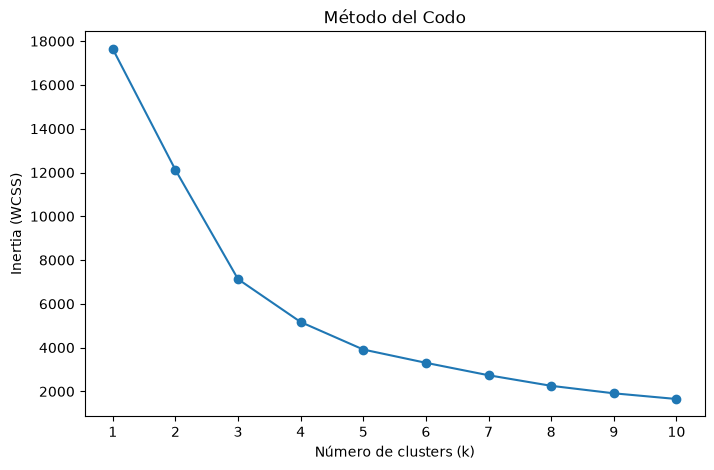

In [13]:
#Algoritmo K-means y Método del codo

inertias = []       #Lista de valores de WCSS o 'distancia' del centro del cluster
k_range = range(1, 11)

for k in k_range:
    kmeans_prueba = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans_prueba.fit(rfm_scaled)
    inertias.append(kmeans_prueba.inertia_)

#Se aplica el algoritmo a los valores de rfm-scaled

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Método del Codo')
plt.xticks(k_range)
plt.show()

Gráfica muestra aproximadamente un valor que sería 'óptimo' de cantidad de clusters como 4, coincidente con las categorías deseadas de clientes, k=4

In [14]:
k_optimo = 4

kmeans_final = KMeans(n_clusters=k_optimo, init='k-means++',n_init=10,random_state=42)
rfm['Cluster'] = kmeans_final.fit_predict(rfm_scaled)  
#El algoritmo asigna los clusters sin escalar

rfm.head()

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
12346.0,326,12,77556.46,0
12347.0,2,8,5633.32,0
12348.0,75,5,2019.40,0
12349.0,19,4,4428.69,0
12350.0,310,1,334.40,1


In [15]:
#Resumen claro de Clusters

resumen_clusters = rfm.groupby('Cluster').agg(
    Recency_promedio=('Recency', 'mean'),
    Frequency_promedio=('Frequency', 'mean'),
    Monetary_promedio=('Monetary', 'mean'),
    Num_Clientes=('Cluster', 'size')
)

resumen_clusters


,Recency_promedio,Frequency_promedio,Monetary_promedio,Num_Clientes
Cluster,,,,
0,66.991931,7.306351,3008.619160,3842
1,463.234000,2.211000,764.479201,2000
2,25.942857,103.742857,83086.079771,35
3,3.500000,212.750000,436835.792500,4


3 - VIP (Recency muy baja, Frequency muy alta, Monetary muy alto)

2 - Leales (Recency baja, Frequency alta, Monetary alto)

0 - En Riesgo (Recency relativamente alta, Frequency baja, Monetary bajo)

1 - Perdidos (Recency muy alto, Frequency muy baja, Monetary muy bajo)

Se verificaron los clientes VIP, para ajustar si es que son empresas

In [16]:
#Verificación de posibles 'outliers'

rfm[rfm['Cluster'] == 3]

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
14156.0,10,156,313946.37,3
14646.0,2,152,528602.52,3
14911.0,1,398,295972.63,3
18102.0,1,145,608821.65,3


Las frequencias altas nos indican que han comprado, desde el inicio de la información, muchas veces, casi regularmente. 
Esto nos dice que estos clientes 'VIP' pueden ser empresas mayoristas con pedidos regulares.
Posiblemente se puede armar un programa directo de B2B con estos clientes

===GRAFICOS INTERACTIVOS===

In [17]:
import plotly.express as px

In [22]:
rfm['Cluster_label'] = rfm['Cluster'].astype(str)
#Se asegura que al graficar marque las diferencias entre clusters bien, y no piense que son valores monetarios

In [19]:
#Scatter 3D interactivo

fig_3d = px.scatter_3d(
    rfm,
    x='Recency',
    y='Frequency',
    z='Monetary',
    color='Cluster_label',
    color_discrete_sequence=px.colors.qualitative.Set1,
    opacity=0.7,
    title='Segmentación de clientes basado en RFM',
    labels={
        'Recency': 'Recencia (días)',
        'Frequency': 'Frecuencia (pedidos)',
        'Monetary': 'Monetario ($)'
    }
)

fig_3d.show()

Se ven claramente las diferencias entre los clusters, visualizando claramente los distintos grupos a tratar

In [20]:
#Gráfico de barras

#Preparación para gráfico
resumen_plot = resumen_clusters.reset_index()
resumen_plot['Cluster'] = resumen_plot['Cluster'].astype(str)
resumen_plot

#Gráficos para comparar Monetary vs Frequency
fig_bar_monetary = px.bar(
    resumen_plot,
    x='Cluster',
    y='Monetary_promedio',
    color='Cluster',
    color_discrete_sequence=px.colors.qualitative.Set1,
    text_auto='.2s',
    title='Gasto promedio por cluster',
    labels={'Monetary_promedio': 'Gasto promedio ($)'}
)
fig_bar_monetary.show()

fig_bar_frequency = px.bar(
    resumen_plot,
    x='Cluster',
    y='Frequency_promedio',
    color='Cluster',
    color_discrete_sequence=px.colors.qualitative.Set1,
    text_auto='.1f',
    title='Frecuencia promedio de pedidos por cluster',
    labels={'Frequency_promedio': 'Pedidos promedio'}
)
fig_bar_frequency.show()

===EXPORTACIÓN DE DATOS CON CLUSTERS===

In [21]:
rfm_export = rfm.drop(columns=['Cluster_label']).reset_index()
rfm_export['Cluster'] = rfm_export['Cluster'].astype(int)

rfm_export.to_csv('data/clientes_segmentados.csv', index=False)

rfm_export.head()

,Customer ID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,12,77556.46,0
1,12347.0,2,8,5633.32,0
2,12348.0,75,5,2019.40,0
3,12349.0,19,4,4428.69,0
4,12350.0,310,1,334.40,1
